# Notebook 04 — Model Evaluation & Performance Analysis

This is the final evaluation notebook. It answers the class requirement:
> *"Analyser les performances du modèle (accuracy, précision, recall, matrice de confusion)"*

All metrics are computed on the **held-out test set** — images the model has **never seen** during training or validation.

**Metrics explained:**
- **Accuracy** = percentage of all correct predictions
- **Precision** = of everything flagged as "tumor", how many actually were?
- **Recall (Sensitivity)** = of all actual tumors, how many did we catch? ← most important
- **F1-Score** = balanced combination of Precision and Recall
- **AUC-ROC** = overall ability to distinguish tumor vs no-tumor (1.0 = perfect, 0.5 = random)
- **Confusion Matrix** = 2×2 table showing correct and incorrect predictions

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', '../requirements.txt', '-q'])
print('✓ All dependencies installed.')

✓ All dependencies installed.


In [2]:
import sys, yaml
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc as sk_auc
)

from src.data.dataset import BrainTumorDataset
from src.data.augmentation import get_val_transform
from src.model.classifier import load_model
from src.explainability.gradcam import generate_gradcam, overlay_heatmap

with open('../config.yaml') as f:
    CFG = yaml.safe_load(f)

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASS_NAMES = CFG['dataset']['class_names']  # ["no_tumor", "tumor"]
model = load_model('../models/classifier_best.pt', DEVICE)
print('Model loaded. Running evaluation on TEST SET only.')

Model loaded. Running evaluation on TEST SET only.


## Step 1 — Run Inference on Test Set

In [3]:
test_dataset = BrainTumorDataset(
    root_dir='../data/Testing',
    transform=get_val_transform(),
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
print(f'Test set: {len(test_dataset)} images | Class counts: {test_dataset.class_counts()}')

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs[:, 1])  # P(tumor)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)
print('Inference complete.')

Test set: 1600 images | Class counts: {'no_tumor': 400, 'tumor': 1200}
Inference complete.


## Step 2 — Full Metrics Table

In [4]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
roc_auc   = roc_auc_score(y_true, y_prob)

# Specificity = TN / (TN + FP) — how well we identify no-tumor cases
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = pd.DataFrame([
    {'Metric': 'Accuracy',        'Value': accuracy,    'Target': '≥ 92%', 'Pass': accuracy >= 0.92},
    {'Metric': 'Precision',       'Value': precision,   'Target': '≥ 85%', 'Pass': precision >= 0.85},
    {'Metric': 'Recall (Sensit.)', 'Value': recall,     'Target': '≥ 95%', 'Pass': recall >= 0.95},
    {'Metric': 'Specificity',     'Value': specificity, 'Target': '≥ 85%', 'Pass': specificity >= 0.85},
    {'Metric': 'F1-Score',        'Value': f1,          'Target': '≥ 0.90','Pass': f1 >= 0.90},
    {'Metric': 'AUC-ROC',         'Value': roc_auc,     'Target': '≥ 0.97','Pass': roc_auc >= 0.97},
])
metrics['Value (%)'] = (metrics['Value'] * 100).round(2).astype(str) + '%'
metrics['Status'] = metrics['Pass'].map({True: '✅ PASS', False: '❌ FAIL'})
print('\n=== TEST SET PERFORMANCE ===')
display(metrics[['Metric', 'Value (%)', 'Target', 'Status']])

print(f'\nRaw counts: TP={tp} | FP={fp} | TN={tn} | FN={fn}')
print(f'False Negatives (missed tumors): {fn} — this is the most critical number.')


=== TEST SET PERFORMANCE ===


,Metric,Value (%),Target,Status
0,Accuracy,97.12%,≥ 92%,✅ PASS
1,Precision,99.83%,≥ 85%,✅ PASS
2,Recall (Sensit.),96.33%,≥ 95%,✅ PASS
3,Specificity,99.5%,≥ 85%,✅ PASS
4,F1-Score,98.05%,≥ 0.90,✅ PASS
5,AUC-ROC,99.73%,≥ 0.97,✅ PASS



Raw counts: TP=1156 | FP=2 | TN=398 | FN=44
False Negatives (missed tumors): 44 — this is the most critical number.


## Step 3 — Confusion Matrix

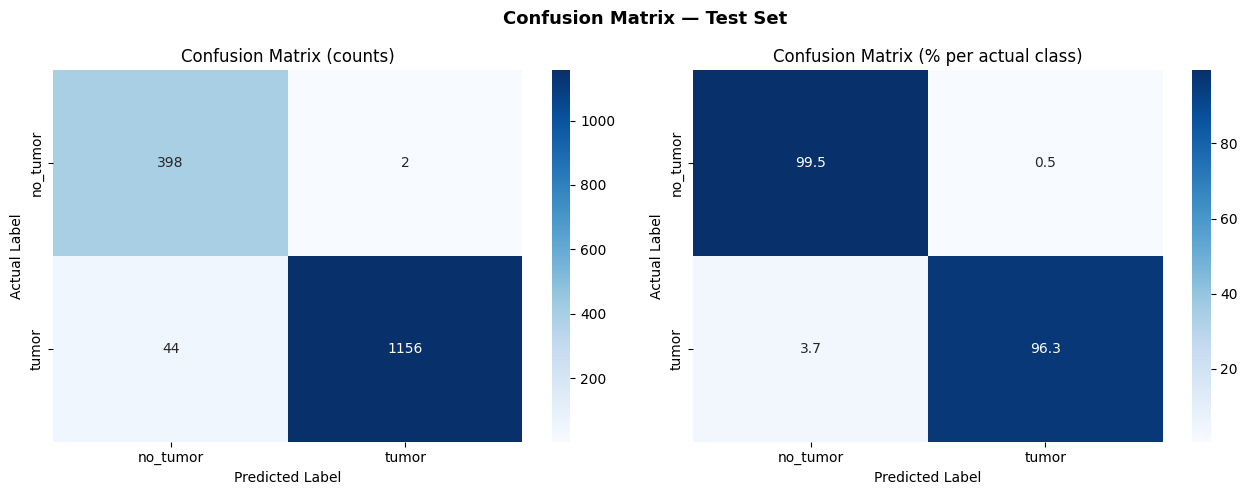


Interpretation:
  Bottom-left (FN): 44 tumors were missed (predicted no_tumor, actually tumor) — WORST CASE
  Top-right   (FP): 2 healthy cases were flagged as tumor — false alarm, less dangerous


In [5]:
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Percentage
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('Confusion Matrix (% per actual class)')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print(f'  Bottom-left (FN): {fn} tumors were missed (predicted no_tumor, actually tumor) — WORST CASE')
print(f'  Top-right   (FP): {fp} healthy cases were flagged as tumor — false alarm, less dangerous')

## Step 4 — ROC Curve

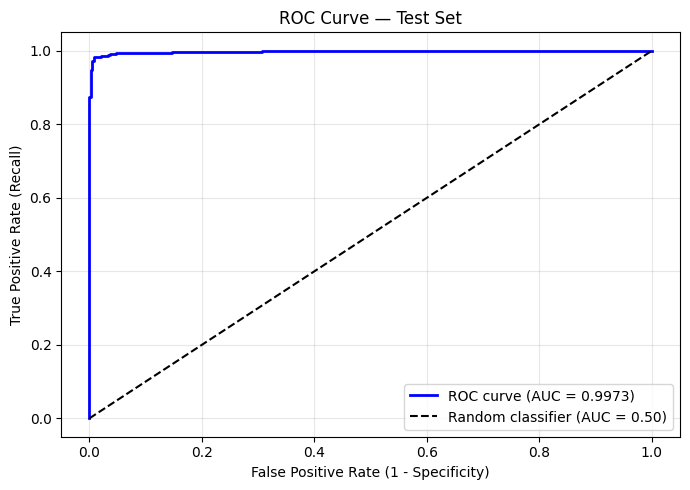

In [6]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_plot = sk_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc_plot:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Failure Analysis: Misclassified Examples with Grad-CAM

Total misclassified: 46 / 1600


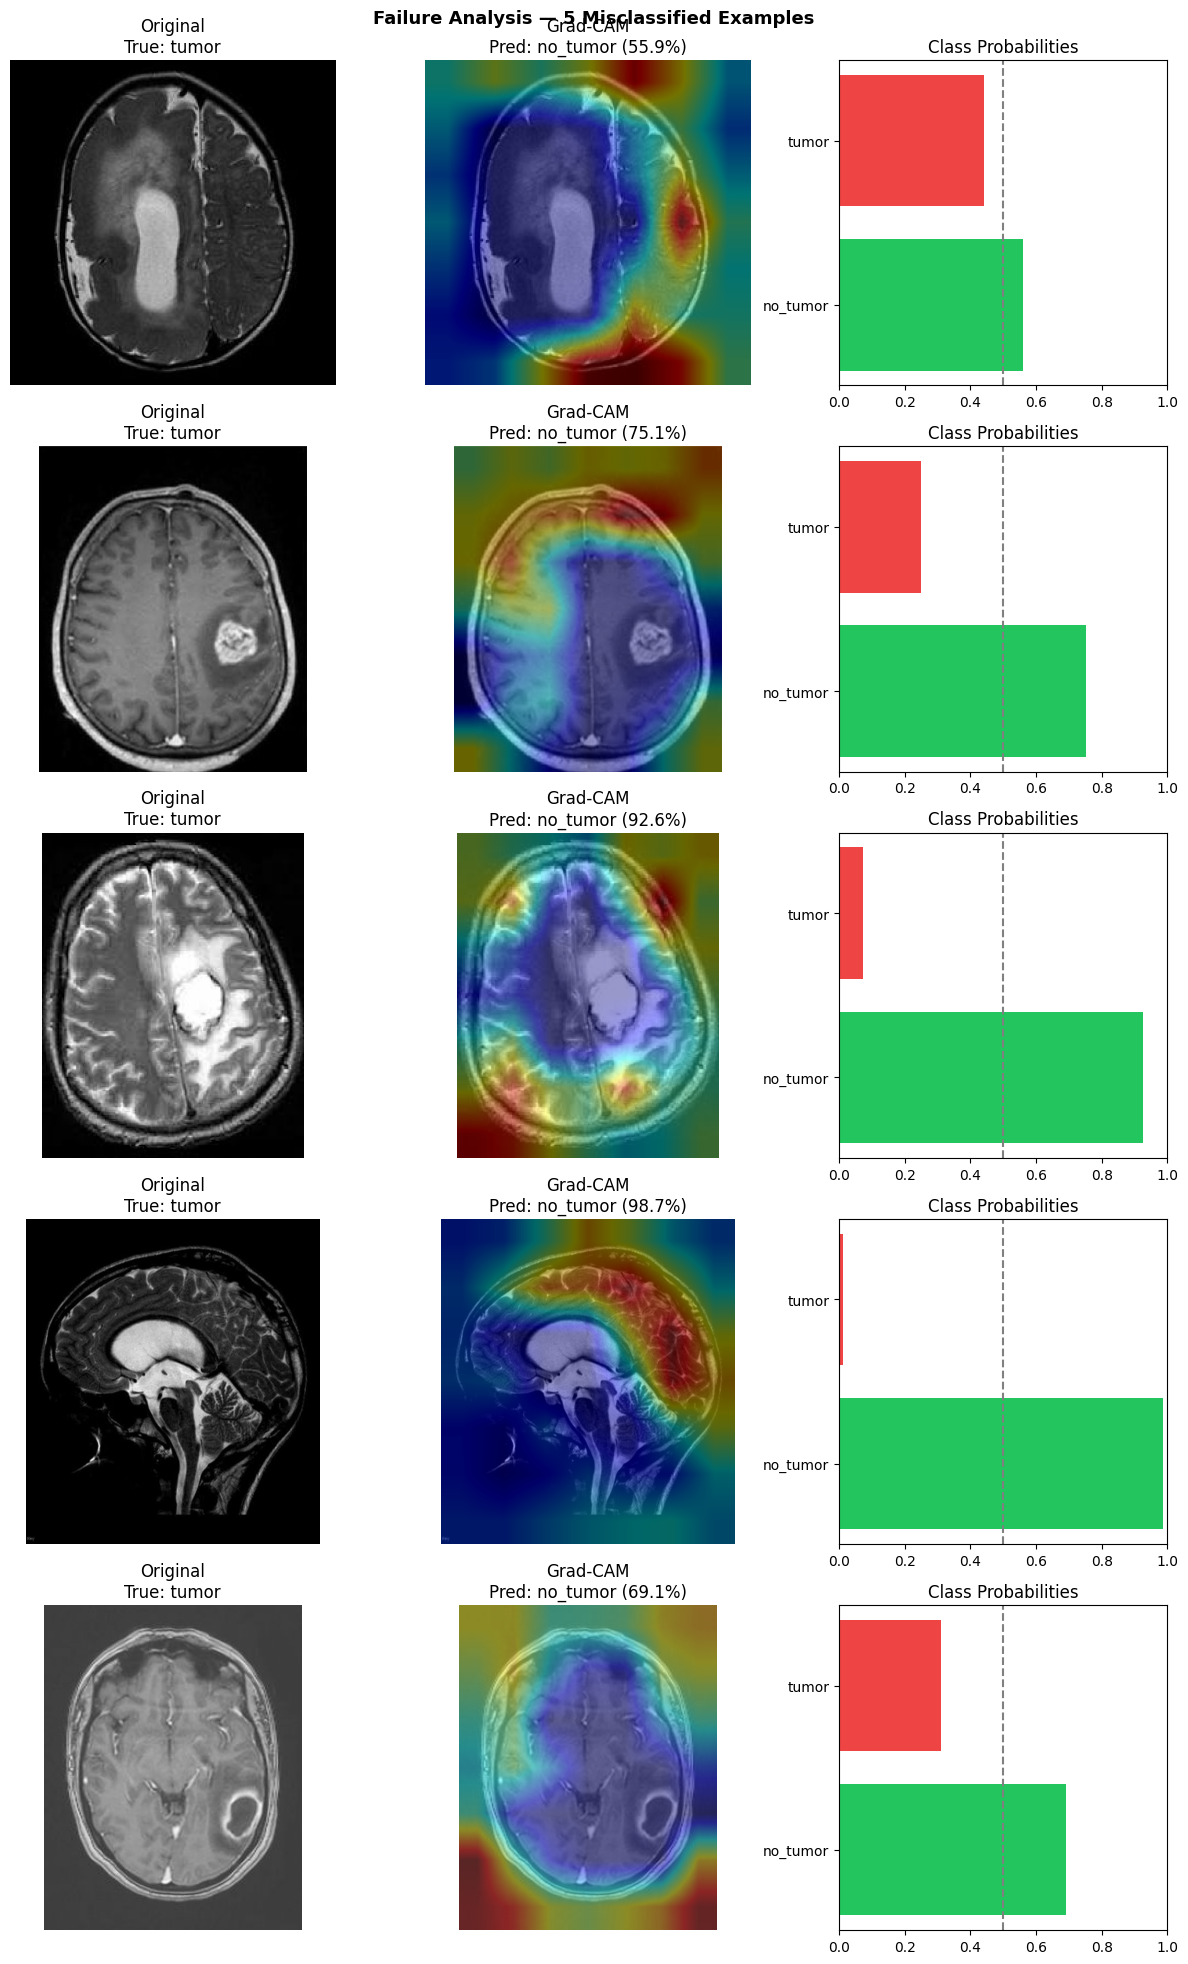


Add your analysis: WHY did the model fail on these cases?
Look at the Grad-CAM: is the model looking at the wrong region?


In [7]:
# Find misclassified images
wrong_indices = np.where(y_pred != y_true)[0]
print(f'Total misclassified: {len(wrong_indices)} / {len(y_true)}')

SHOW_N = min(5, len(wrong_indices))
sample_wrong = wrong_indices[:SHOW_N]

# Re-run with individual images to get Grad-CAM
import torch.nn.functional as F
from src.data.preprocessing import get_inference_transform

transform = get_val_transform()
fig, axes = plt.subplots(SHOW_N, 3, figsize=(12, 4 * SHOW_N))
if SHOW_N == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_wrong):
    img_path, true_label = test_dataset.samples[idx]
    pil_img = __import__('PIL').Image.open(img_path).convert('RGB')
    tensor  = transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze()

    pred_label = logits.argmax().item()
    gradcam_map = generate_gradcam(model, tensor, pred_label)
    overlay     = overlay_heatmap(pil_img, gradcam_map)

    axes[row][0].imshow(pil_img)
    axes[row][0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}')
    axes[row][0].axis('off')

    axes[row][1].imshow(overlay)
    axes[row][1].set_title(f'Grad-CAM\nPred: {CLASS_NAMES[pred_label]} ({probs[pred_label]*100:.1f}%)')
    axes[row][1].axis('off')

    prob_bar = axes[row][2]
    prob_bar.barh(CLASS_NAMES, probs.cpu().numpy(), color=['#22c55e', '#ef4444'])
    prob_bar.set_xlim(0, 1)
    prob_bar.set_title('Class Probabilities')
    prob_bar.axvline(0.5, color='gray', linestyle='--')

plt.suptitle(f'Failure Analysis — {SHOW_N} Misclassified Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAdd your analysis: WHY did the model fail on these cases?')
print('Look at the Grad-CAM: is the model looking at the wrong region?')

## Step 6 — External Validation (Generalization Test)

In [8]:
# Test on navoneel/brain-mri-images-for-brain-tumor-detection (different source)
# Download and place in data/external/
# Format: data/external/yes/ (tumor) and data/external/no/ (no_tumor)

EXTERNAL_DIR = Path('../data/external')
if not EXTERNAL_DIR.exists():
    print('External dataset not found at data/external/')
    print('Download from: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection')
    print('Place images in data/external/yes/ and data/external/no/')
else:
    from src.data.dataset import BrainTumorDataset

    # Map navoneel's folder names to binary labels
    ext_samples = []
    for label_name, label_int in [('yes', 1), ('no', 0)]:
        folder = EXTERNAL_DIR / label_name
        if folder.exists():
            for p in folder.glob('*.jpg'):
                ext_samples.append((p, label_int))

    print(f'External validation set: {len(ext_samples)} images')

    ext_preds, ext_labels = [], []
    for img_path, label in ext_samples:
        from PIL import Image as PILImage
        pil_img = PILImage.open(img_path).convert('RGB')
        tensor  = get_val_transform()(pil_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(tensor).argmax().item()
        ext_preds.append(pred)
        ext_labels.append(label)

    ext_recall = recall_score(ext_labels, ext_preds, pos_label=1, zero_division=0)
    ext_acc    = accuracy_score(ext_labels, ext_preds)
    print(f'External Accuracy: {ext_acc*100:.1f}%')
    print(f'External Recall:   {ext_recall*100:.1f}%')

    recall_drop = recall - ext_recall
    if recall_drop > 0.10:
        print(f'WARNING: Recall dropped {recall_drop*100:.1f}% on external data — possible overfitting!')
    else:
        print(f'OK: Recall drop of {recall_drop*100:.1f}% — model generalizes reasonably.')

External dataset not found at data/external/
Download from: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
Place images in data/external/yes/ and data/external/no/


## Summary Table for Report

In [9]:
summary = f"""
╔══════════════════════════════════════════╗
║  FINAL EVALUATION RESULTS — TEST SET    ║
╠══════════════════════════════════════════╣
║  Accuracy   : {accuracy*100:5.2f}%  (target ≥ 92%)  ║
║  Precision  : {precision*100:5.2f}%  (target ≥ 85%)  ║
║  Recall     : {recall*100:5.2f}%  (target ≥ 95%)  ║
║  Specificity: {specificity*100:5.2f}%                   ║
║  F1-Score   : {f1:.4f}  (target ≥ 0.90) ║
║  AUC-ROC    : {roc_auc:.4f}  (target ≥ 0.97) ║
╠══════════════════════════════════════════╣
║  True Positives  (TP): {tp:4d}              ║
║  False Positives (FP): {fp:4d}  (false alarm) ║
║  True Negatives  (TN): {tn:4d}              ║
║  False Negatives (FN): {fn:4d}  (missed tumor) ║
╚══════════════════════════════════════════╝
"""
print(summary)
with open('../docs/evaluation_summary.txt', 'w') as f:
    f.write(summary)
print('Saved to docs/evaluation_summary.txt')


╔══════════════════════════════════════════╗
║  FINAL EVALUATION RESULTS — TEST SET    ║
╠══════════════════════════════════════════╣
║  Accuracy   : 97.12%  (target ≥ 92%)  ║
║  Precision  : 99.83%  (target ≥ 85%)  ║
║  Recall     : 96.33%  (target ≥ 95%)  ║
║  Specificity: 99.50%                   ║
║  F1-Score   : 0.9805  (target ≥ 0.90) ║
║  AUC-ROC    : 0.9973  (target ≥ 0.97) ║
╠══════════════════════════════════════════╣
║  True Positives  (TP): 1156              ║
║  False Positives (FP):    2  (false alarm) ║
║  True Negatives  (TN):  398              ║
║  False Negatives (FN):   44  (missed tumor) ║
╚══════════════════════════════════════════╝



UnicodeEncodeError: 'charmap' codec can't encode characters in position 2-45: character maps to <undefined>